## Exploratory Data Analysis (EDA)

To improve computational efficiency while maintaining analytical reliability, exploratory data analysis (EDA) was conducted using the **100,000-record stratified development sample** (`loans_dev_100k`) rather than the full dataset. This sample preserves the original target class distribution between defaulted and non-defaulted loans, ensuring that observed patterns remain representative of the broader development data.

The objective of this stage is to develop an informed understanding of the dataset, assess overall data quality, and uncover patterns that will guide subsequent preprocessing, feature engineering, and model development.

### ============================================================
#### Loans EDA
### ============================================================

## Exploratory Data Analysis: Loans Dataset

In [2]:
# Import core libraries for data manipulation, visualization,
# statistical analysis, configuration handling, and notebook setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
warnings.filterwarnings('ignore')

os.makedirs('../report/figures', exist_ok=True)

In [3]:
# Load the processed development dataset and verify its dimensions
# and baseline default rate before exploratory analysis

df = pd.read_parquet('../data/processed/loans_dev_100k.parquet')
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Default rate: {df["default_flag"].mean():.4f}')

Loaded: 100,000 rows x 153 columns
Default rate: 0.1997


### 1. Default rate by loan grade (MODEL_EXCLUDED: EDA only)
Grade is the lender's own risk score. 

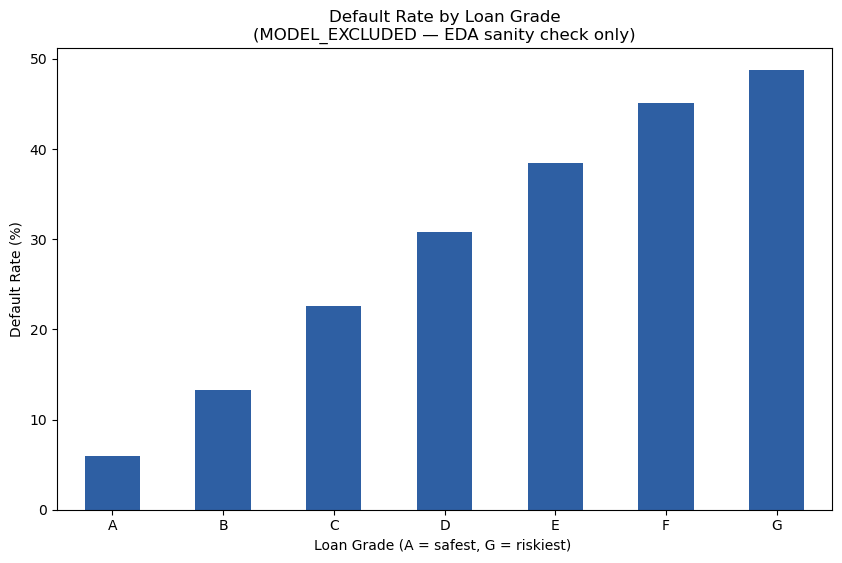

Saved: eda_loans_01_default_by_grade.png


In [4]:
# Default rate by loan grade

grade_default = (df.groupby('grade')['default_flag'].mean()* 100).sort_index()

grade_default.plot(kind='bar', color = '#2E5FA3', figsize=(10,6))

plt.title('Default Rate by Loan Grade\n(MODEL_EXCLUDED — EDA sanity check only)')
plt.xlabel('Loan Grade (A = safest, G = riskiest) ')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.savefig('../report/figures/eda_loans_01_default_by_grade.png')
plt.show()
print('Saved: eda_loans_01_default_by_grade.png')

**Findings:**

Grade A default rate: Safest

Grade G default rate: Riskiest

The lender-assigned loan grade shows a **strong monotonic relationship with default risk**, with realised default rates rising steadily from ~6% (Grade A) to ~49% (Grade G). This confirms the lender's grading system effectively differentiates credit risk and makes loan grade highly predictive. However, because it is a lender-derived risk assessment rather than an independently observable borrower characteristic, it is excluded from the model to prevent information leakage.

### 2. Default rate by loan purpose

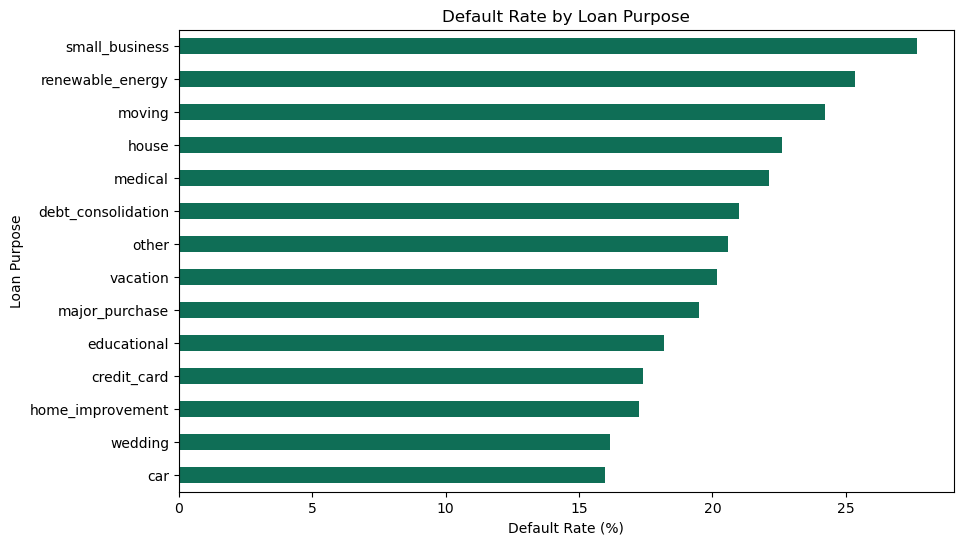

Saved: eda_loans_02_default_by_purpose.png


In [5]:
# Default rate by loan grade

purpose_default = (df.groupby('purpose')['default_flag'].mean()* 100).sort_values()

purpose_default.plot(kind='barh', color='#0F6E56', figsize=(10,6))

plt.title('Default Rate by Loan Purpose')
plt.xlabel('Default Rate (%)')
plt.ylabel('Loan Purpose')
plt.xticks(rotation=0)
plt.savefig('../report/figures/eda_loans_02_default_by_purpose.png')
plt.show()
print('Saved: eda_loans_02_default_by_purpose.png')

**Findings:** 

Default rates vary notably by loan purpose, with **small business**, renewable energy, and moving loans showing the **highest default risk**, while **car**, wedding, and home improvement loans have the **lowest default rates**. This suggests that borrower repayment behaviour differs meaningfully depending on the intended use of the loan.

### 3. Vintage default curve

**Data note:** The vintage curve uses the full dataset (`loans_clean.parquet`) rather than
the 100k dev sample used throughout the rest of this notebook. Early cohorts (2008–2010)
have very few loans in the full dataset to begin with; the stratified dev sample does not
preserve vintage proportions, leaving these cohorts with near-zero observations and
unreliable default rate estimates. The full dataset is the minimum requirement for any
cohort-level analysis where thin representation would distort findings.

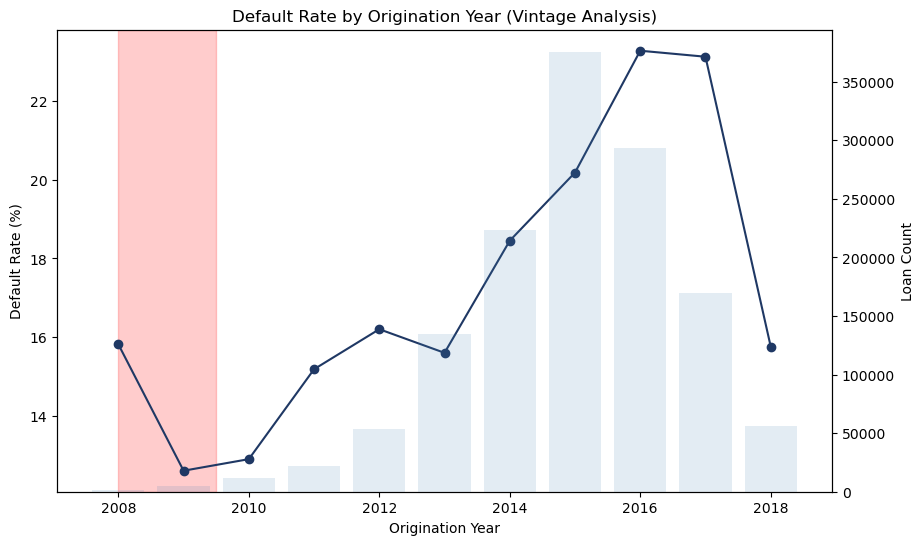

Saved: eda_loans_03_vintage_curve.png


In [6]:
# Default rate by origination year (vintage analysis)

full_df = pd.read_parquet('../data/processed/loans_clean.parquet') 

full_df['issue_year'] = pd.to_datetime(full_df['issue_d']).dt.year

vintage = full_df.groupby('issue_year')['default_flag'].mean() * 100
loan_count = full_df.groupby('issue_year')['default_flag'].count()

vintage = vintage[loan_count >= 500]
loan_count = loan_count[loan_count >= 500]

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(vintage.index, vintage.values, marker='o', color='#1F3864')
ax1.set_title('Default Rate by Origination Year (Vintage Analysis)')
ax1.set_xlabel('Origination Year')
ax1.set_ylabel('Default Rate (%)')
ax1.axvspan(2008, 2009.5, color='red', alpha=0.2)

ax2 = ax1.twinx()
ax2.bar(loan_count.index, loan_count.values, color='steelblue', alpha=0.15)
ax2.set_ylabel('Loan Count')

plt.savefig('../report/figures/eda_loans_03_vintage_curve.png')
plt.show()

print('Saved: eda_loans_03_vintage_curve.png')

**Findings:** 

Default rates were lowest for 2008–2009 vintages (~ 13%), reflecting
**crisis-era credit tightening and extremely low origination volumes** rather than favourable
borrower quality. Rates rose steadily through 2016–2017 (~ 23%), consistent with rapid
platform growth and progressive loosening of credit standards. The 2018 decline reflects
truncation bias — loans have not yet fully seasoned. The Global Financial Crisis (GFC) shading is retained as a
reference marker; its effect manifests in volume suppression rather than elevated default
rates.

### 4. KDE plots: Interest rate, DTI, FICO

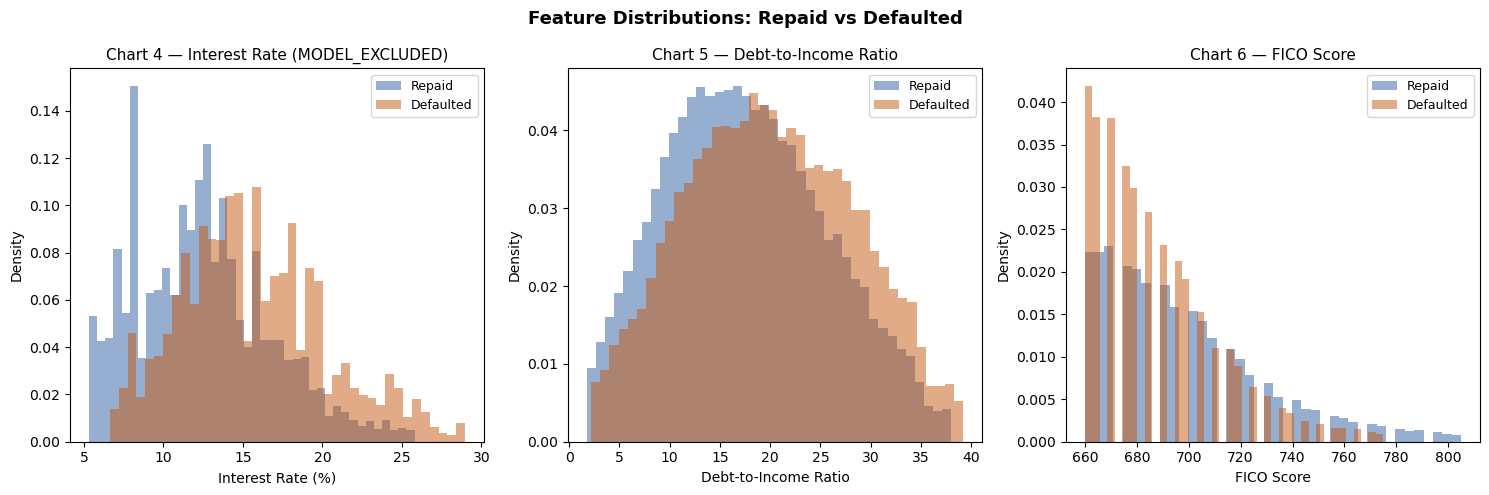

In [7]:
# Compare feature distributions between repaid and defaulted loans
# using normalized histograms with outlier trimming

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cols = [
    ('int_rate',       'Interest Rate (%)',     'Chart 4 — Interest Rate (MODEL_EXCLUDED)'),
    ('dti',            'Debt-to-Income Ratio',  'Chart 5 — Debt-to-Income Ratio'),
    ('fico_range_low', 'FICO Score',            'Chart 6 — FICO Score'),
]

for ax, (col, xlabel, title) in zip(axes, cols):
    for flag, label, color in [(0, 'Repaid', '#2E5FA3'), (1, 'Defaulted', '#C45911')]:
        subset = df[df['default_flag'] == flag][col].dropna()

         # Remove extreme outliers using 1st–99th percentile bounds
        subset = subset[subset.between(subset.quantile(0.01), subset.quantile(0.99))]
        ax.hist(subset, bins=40, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Feature Distributions: Repaid vs Defaulted', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/figures/eda_loans_04_06_kdes.png', dpi=150)
plt.show()

**Findings:** 

The distribution plots show clear separation between repaid and defaulted loans across key borrower risk characteristics. **Defaulted loans tend to have higher interest rates, higher debt-to-income (DTI) ratios, and lower FICO scores** compared with repaid loans. This suggests that weaker borrower credit quality and higher financial leverage are associated with an increased likelihood of loan default, consistent with expected credit risk behaviour.

### 5. Class imbalance

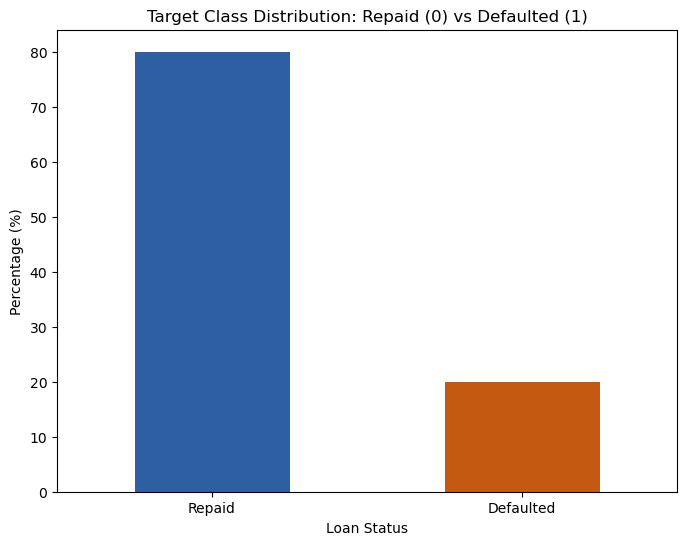

Saved: eda_loans_07_class_imbalance.png


In [8]:
# Class imbalance check

class_dist = (df['default_flag'].value_counts(normalize=True) * 100).sort_index()

class_dist.index = ['Repaid', 'Defaulted']

class_dist.plot(kind='bar', color=['#2E5FA3', '#C45911'], figsize=(8,6))

plt.title('Target Class Distribution: Repaid (0) vs Defaulted (1)')
plt.xlabel('Loan Status')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.savefig('../report/figures/eda_loans_07_class_imbalance.png')
plt.show()

print('Saved: eda_loans_07_class_imbalance.png')

**Findings:** 

The target variable shows a moderate class imbalance, with approximately **80% of loans classified as repaid** and **20% as defaulted**. While the imbalance is not extreme, it is sufficient to bias standard classification models toward the majority (repaid) class, potentially reducing the model’s ability to correctly identify defaults, which are the primary risk events of interest.

To address this during model development, imbalance-aware techniques will be applied, including **`class_weight='balanced'` for Logistic Regression** and **`scale_pos_weight` for tree-based boosting models such as XGBoost and LightGBM**, to improve the model’s sensitivity to the minority default class.

### 6. Correlation heatmap (origination-time numeric features)

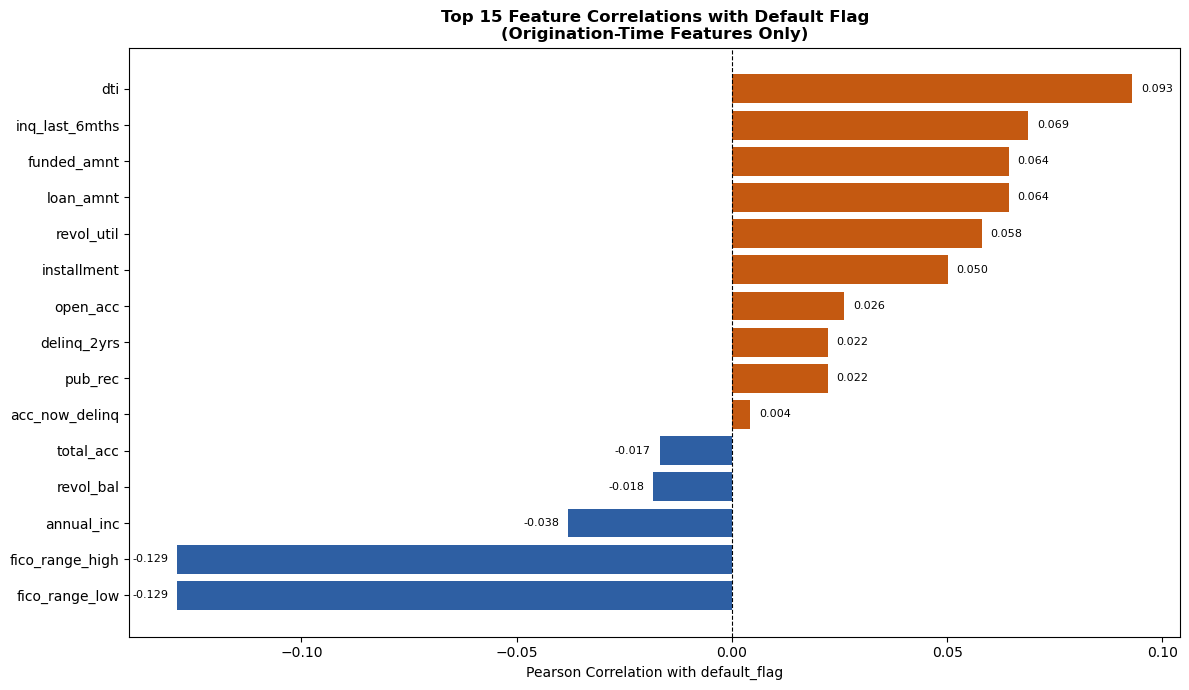

In [9]:
# Load the finalized consistent feature configuration generated during the data preparation stage
# to define the approved origination feature set for modeling

with open('../data/processed/consistent_features.json', 'r') as f:
    config = json.load(f)

CONSISTENT_FEATURES = config['consistent_features']

origination_features = [
    c for c in CONSISTENT_FEATURES
    if df[c].dtype in ['float64', 'int64']
]

corr_with_target = (
    df[origination_features]
    .apply(lambda col: col.corr(df['default_flag']))
    .dropna()
)

# Keep top 15 by absolute correlation — drops near-zero noise
top15 = corr_with_target.abs().sort_values(ascending=False).head(15).index
corr_plot = corr_with_target[top15].sort_values()

colors = ['#C45911' if v > 0 else '#2E5FA3' for v in corr_plot.values]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(corr_plot.index, corr_plot.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

# Add value labels on bars
for bar, val in zip(bars, corr_plot.values):
    ax.text(val + (0.002 if val >= 0 else -0.002), bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

ax.set_title('Top 15 Feature Correlations with Default Flag\n(Origination-Time Features Only)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Pearson Correlation with default_flag')
plt.tight_layout()
plt.savefig('../report/figures/eda_loans_08_correlation.png')
plt.show()

**Findings:** 

FICO score is the strongest protective feature (−0.129), confirming credit history quality is the most important negative predictor of default at origination. DTI is the strongest risk-increasing feature (0.093) — borrowers carrying high debt relative to income default more often. Recent credit inquiries (0.069) and revolving utilisation (0.058) add incremental positive signal. Notably, all correlations are weak in absolute terms (max 0.129), which is expected — default is a non-linear, multi-factor outcome. This is precisely why tree-based models will outperform logistic regression on this dataset.

### 7. Default Rate by Calendar Quarter (pooled across vintages)

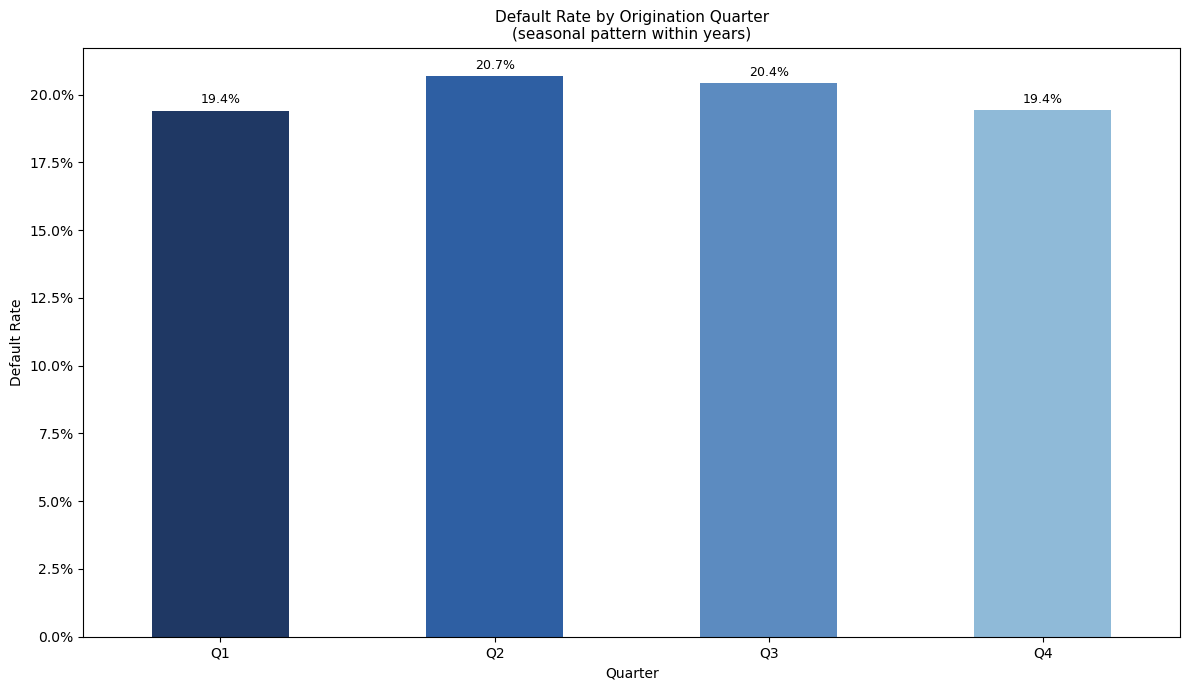

In [10]:
# Derive loan origination quarter from the parsed issue date column, with fallback conversion from the raw issue_d string field if needed

df['vintage_quarter'] = (
    df['issue_d_parsed'].dt.quarter
    if 'issue_d_parsed' in df.columns
    else pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce').dt.quarter
)

# Calculate default rate by quarter
q_default = df.groupby('vintage_quarter')['default_flag'].mean()

# Plot quarterly default pattern
fig, ax = plt.subplots(figsize=(12, 7))
q_default.plot.bar(
    ax=ax, 
    color=['#1F3864','#2E5FA3','#5C8BC0','#8FBAD8']
)

ax.set_title('Default Rate by Origination Quarter\n(seasonal pattern within years)', fontsize=11)
ax.set_xlabel('Quarter')
ax.set_ylabel('Default Rate')
ax.set_xticklabels(['Q1','Q2','Q3','Q4'], rotation=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.1%}'))

ax.bar_label(
    ax.containers[0],
    labels=[f'{v:.1%}' for v in q_default],
    padding=3, fontsize=9
)


plt.tight_layout()
plt.savefig('../report/figures/eda_loans_09_quarterly.png')
plt.show()

**Findings:** 

The spread between the highest and lowest quarter is only **1.3 percentage points**, with Q2 and Q3 originations defaulting marginally more often than Q1 and Q4.

Quarter of origination, on its own, is not a meaningful predictor of default. Any seasonal effect in the underwriting funnel — tax-season refinancing, summer discretionary borrowing, year-end credit pulls — is too small to surface once aggregated across all vintage years. `vintage_quarter` will **not** be carried forward as a feature in the modeling phase. Whatever signal it might carry is already absorbed by stronger variables such as `purpose`, `dti`, and FICO. If a vintage effect matters for this portfolio, it likely lives at the **year** level (macro credit cycles), not the quarter level — a candidate for follow-up analysis.

This chart pools all origination years into four buckets, so it reflects calendar-quarter averages rather than a true within-year seasonal pattern. A vintage-by-vintage view would require grouping on both `issue_year` and `vintage_quarter`.

### 8. Loan amount distribution by default status

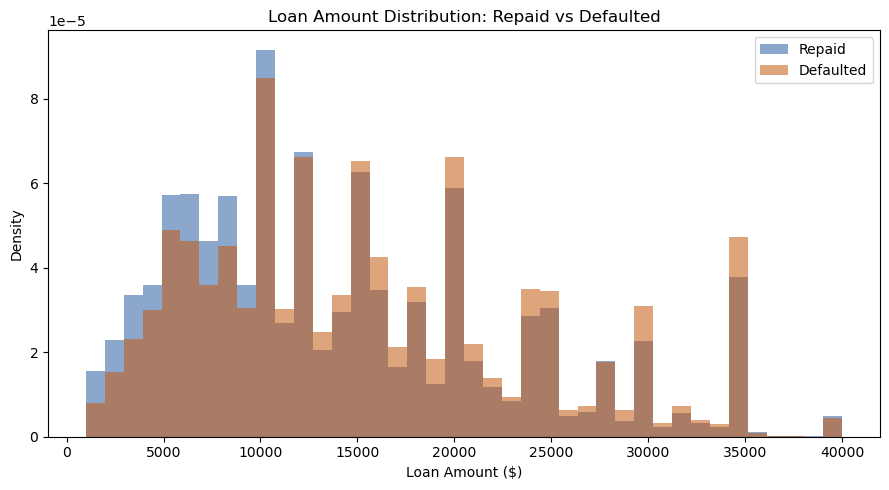

In [11]:
# Compare loan amount distributions between repaid and defaulted loans

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df[df['default_flag'] == 0]['loan_amnt'].dropna(),
        bins=40, alpha=0.55, color='#2E5FA3',
        label='Repaid', density=True)

ax.hist(df[df['default_flag'] == 1]['loan_amnt'].dropna(),
        bins=40, alpha=0.55, color='#C45911',
        label='Defaulted', density=True)

ax.set(title='Loan Amount Distribution: Repaid vs Defaulted',
       xlabel='Loan Amount ($)',
       ylabel='Density')

ax.legend()

plt.tight_layout()
plt.savefig('../report/figures/eda_loans_10_loan_amount.png')
plt.show()

**Findings:**  
The loan amount distributions for repaid and defaulted loans show substantial overlap, indicating that loan size alone is not a strong standalone predictor of default. However, defaulted loans appear slightly more concentrated in the higher loan amount ranges, suggesting that larger borrowing amounts may be associated with increased repayment risk. Most loans for both groups are concentrated below approximately $20,000.

### ============================================================
#### Macro EDA
### ============================================================

## Exploratory Data Analysis: Macro

In [12]:
# Load macro_panel dataset generated during the data preparation stage

macro = pd.read_parquet('../data/processed/macro_panel.parquet')
print(f'Loaded: {macro.shape}')
print(macro.tail(3).to_string(index=False))

Loaded: (317, 6)
      date  overnight_rate  unemployment_rate   cpi  debt_service_ratio  consumer_insolvencies
2026-03-01        2.260870                6.7 167.4               14.57                  167.4
2026-04-01        2.261905                6.9 168.0               14.57                  168.0
2026-05-01        2.250000                6.9 168.0               14.57                  168.0


### 1. Multi-Panel Macroeconomic Time Series with Major Economic Stress Periods Highlighted

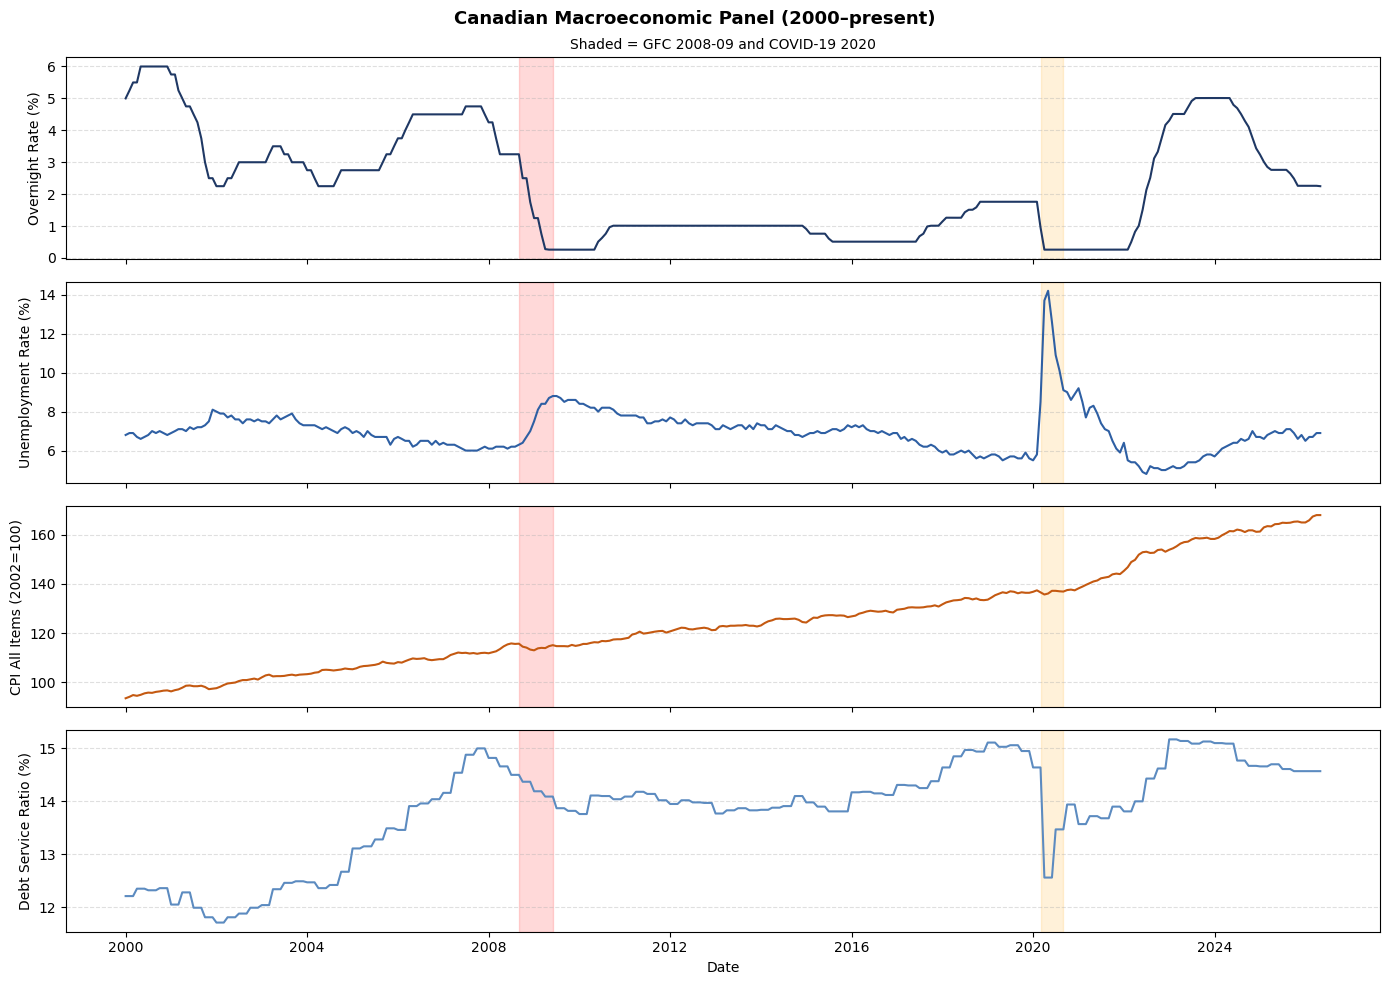

Saved


In [13]:
# Plot key Canadian macroeconomic indicators over time

fig, axes = plt.subplots(4, 1, figsize=(14,10), sharex=True)
fig.suptitle('Canadian Macroeconomic Panel (2000–present)', fontsize=13, fontweight='bold')

series = [
    ('overnight_rate',    'Overnight Rate (%)',         '#1F3864'),
    ('unemployment_rate', 'Unemployment Rate (%)',      '#2E5FA3'),
    ('cpi',               'CPI All Items (2002=100)',   '#C45911'),# CPI base verified: 2002 annual avg = 100.0 (StatCan all-items, base 2002=100)
    ('debt_service_ratio', 'Debt Service Ratio (%)', '#5C8BC0')
]

for ax, (col, ylabel, color) in zip(axes, series):
    ax.plot(macro['date'], macro[col], color=color, linewidth=1.5)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Shade/highlight key stress episodes (major economic stress periods)
    ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-06-01'),
               alpha=0.15, color='red')
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-09-01'),
               alpha=0.15, color='orange')

axes[0].set_title('Shaded = GFC 2008-09 and COVID-19 2020', fontsize=10)
axes[3].set_xlabel('Date')
plt.tight_layout()
plt.savefig('../report/figures/eda_macro_01_04_timeseries.png', bbox_inches='tight')
plt.show()
print('Saved')

**Findings from Macroeconomic Panel — Interpretation (2000–present):**

These four Canadian indicators trace the credit environment behind every loan
vintage in the dataset, with the GFC (2008–09) and COVID-19 (2020) shaded as
reference shocks. They are best read as one connected story rather than four
separate lines: inflation and unemployment drive the Bank of Canada's policy
rate, and that rate in turn shapes how heavily households are burdened by debt.

The **overnight rate** sits at the centre of that story. It moves sharply
against the cycle — cut to its ~0.25% effective floor in both crises to cushion
the economy, then raised in the steepest tightening of the whole period (to ~5%
in 2022–23) to bring post-pandemic inflation back under control. Because it sets
the floor for all borrowing costs, its swings ripple through the other panels.

**Unemployment** is where those shocks turn into credit risk, since job loss is
the main reason borrowers miss payments — making it the strongest macro signal
the model is likely to find. Its two crisis responses look nothing alike: the
GFC ground unemployment slowly up to ~8.5%, while COVID drove it almost
vertically to ~14% before an equally fast recovery. That contrast in shock
*shape*, not just depth, is what a robust model has to survive.

The **CPI** panel records the price *level* rather than the inflation rate, so
it climbs almost continuously; what matters is its slope. Prices rose gently for
two decades before steepening sharply after 2021 — the inflation surge that
forced the rate hikes in the first panel, closing the loop between the two.

The **debt service ratio** measures how much of household income goes to debt
payments, capturing borrower fragility: high-DSR vintages default harder when a
shock lands. It climbed toward ~15% before the GFC, drifted sideways through the
low-rate 2010s, and rebounded to record highs after 2021 as payment deferrals
ended and rates climbed.

**Why the DSR *fell* during COVID-19.** Its path through COVID is the panel's most counter-intuitive moment. Despite the
worst of the disruption, the DSR *fell* to ~12.5% in 2020, because four forces
pushed the same way at once: rate cuts to ~0.25% lightened interest costs,
large-scale loan deferrals suspended required payments, Canada Emergency Response Benefit (CERB) and related
transfers held up disposable income, and lockdowns suppressed spending and new
borrowing. With payments shrinking while income held, the share devoted to debt
servicing dropped — but this was mechanical relief engineered by policy, not a
genuine strengthening of household balance sheets, as the rapid snap-back to
record highs once deferrals expired confirms.

Taken together, the panel frames the task ahead: unemployment as the leading
default driver, the DSR as a gauge of vulnerability, the overnight rate
transmitting cost pressure with a lag, and inflation eroding real incomes — with
the two shaded episodes offering a natural pair of stress scenarios, one slow
and deep, the other sharp but cushioned.

## 2. Consumer insolvencies vs unemployment (dual axis)

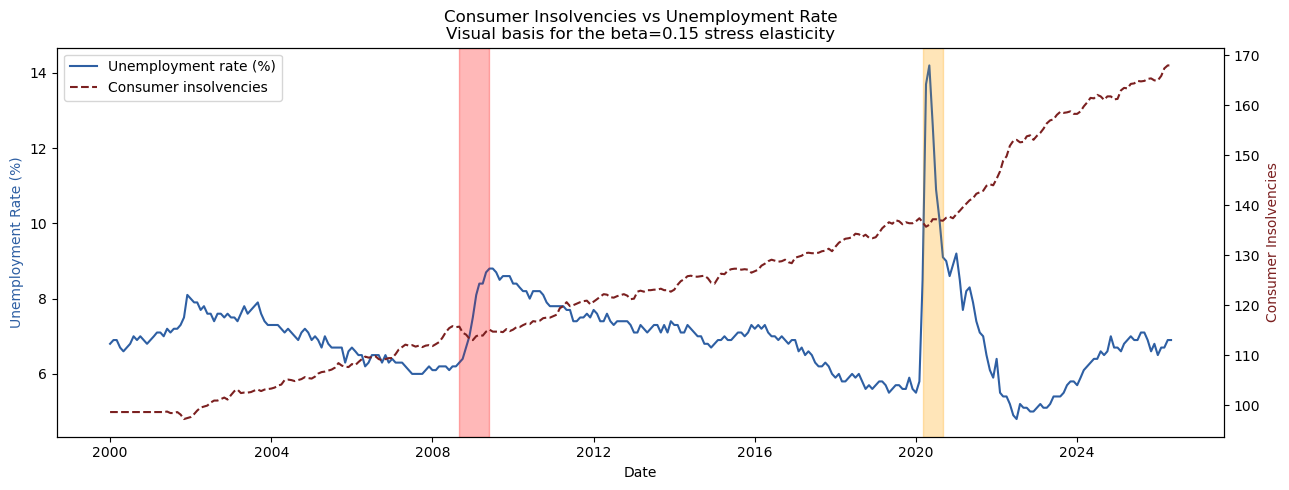

Saved: eda_macro_05_insolvencies_vs_unemp.png


In [14]:
# Plot oConsumer insolvencies and unemployment over time

fig, ax1 = plt.subplots(figsize=(13,5))
ax2 = ax1.twinx()

ax1.plot(macro['date'], macro['unemployment_rate'],
         color='#2E5FA3', linewidth=1.5, label='Unemployment rate (%)')
ax2.plot(macro['date'], macro['consumer_insolvencies'],
         color='#7B2020', linewidth=1.5, linestyle='--', label='Consumer insolvencies')

for ax in [ax1, ax2]:
    ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-06-01'),
               alpha=0.15, color='red')
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-09-01'),
               alpha=0.15, color='orange')

ax1.set_xlabel('Date')
ax1.set_ylabel('Unemployment Rate (%)', color='#2E5FA3')
ax2.set_ylabel('Consumer Insolvencies', color='#7B2020')
ax1.set_title('Consumer Insolvencies vs Unemployment Rate\n'
              'Visual basis for the beta=0.15 stress elasticity', fontsize=12)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[0].set_title('Shaded = GFC 2008-09 and COVID-19 2020', fontsize=10)
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
plt.tight_layout()
plt.savefig('../report/figures/eda_macro_05_insolvencies_vs_unemp.png')
plt.show()
print('Saved: eda_macro_05_insolvencies_vs_unemp.png')

**Findings from Consumer Insolvencies vs Unemployment:**

Unemployment (left axis) and consumer insolvencies (right axis) share a timeline
but use independent scales, so the chart compares the *timing and direction* of
the two series rather than their absolute levels — the visual basis for the
β = 0.15 stress elasticity used in modelling phase.

The two crisis episodes read very differently:

- **GFC (2008–09):** the relationship the elasticity assumes. Unemployment
  climbs to ~8.8% and insolvencies rise with it — the clean co-movement that
  justifies treating insolvency risk as sensitive to labour-market stress.
- **COVID-19 (2020):** a striking *decoupling*. Unemployment spikes to ~14%, yet
  insolvencies flatten and dip rather than follow. The same policy response that
  pushed down the debt service ratio — CERB transfers, payment deferrals, and
  disrupted court filings — temporarily severed the usual link between job loss
  and insolvency.

Beneath both, insolvencies follow a steady long-run upward trend (population and
household-debt growth), so the cyclical signal is the *deviation around that
trend*, not the rising level itself.

**Implication for β:** the elasticity is best supported by normal-times
co-movement and the GFC, where no large offsetting policy cushioned the shock.
COVID is the instructive exception — it shows the relationship can be broken by
aggressive intervention, which is exactly why the stress multiplier is treated
as a scenario *assumption*, not a fixed law.